# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: nizham aufar
- Email: nizham.aufar.tik23@stu.pnj.ac.id
- Id Dicoding: nizhamaufar

## Persiapan

### Menyiapkan library yang dibutuhkan

In [58]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

In [59]:
df = pd.read_csv('dataset/data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [61]:
# definisikan fitur kategorikal dan numerikal
categorical_cols = ['Marital_status', 'Application_mode', 'Course', 
                    'Daytime_evening_attendance', 'Previous_qualification', 
                    'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 
                    'Mothers_occupation', 'Fathers_occupation', 'Displaced', 
                    'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 
                    'Gender', 'Scholarship_holder', 'International', 'Status']

numerical_cols = ['Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment', 
                  'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 
                  'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 
                  'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 
                  'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 
                  'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 
                  'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 
                  'Unemployment_rate', 'Inflation_rate', 'GDP']

print(f"Jumlah fitur kategorikal: {len(categorical_cols)}")
print(f"Jumlah fitur numerikal: {len(numerical_cols)}")

Jumlah fitur kategorikal: 18
Jumlah fitur numerikal: 18


### EDA univariate

/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_22896/1828917967.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='viridis', ax=axes[0])
/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_22896/1828917967.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2', ax=axes[1])
/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_22896/1828917967.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Scholarship_holder', palette='Set3', ax=axe

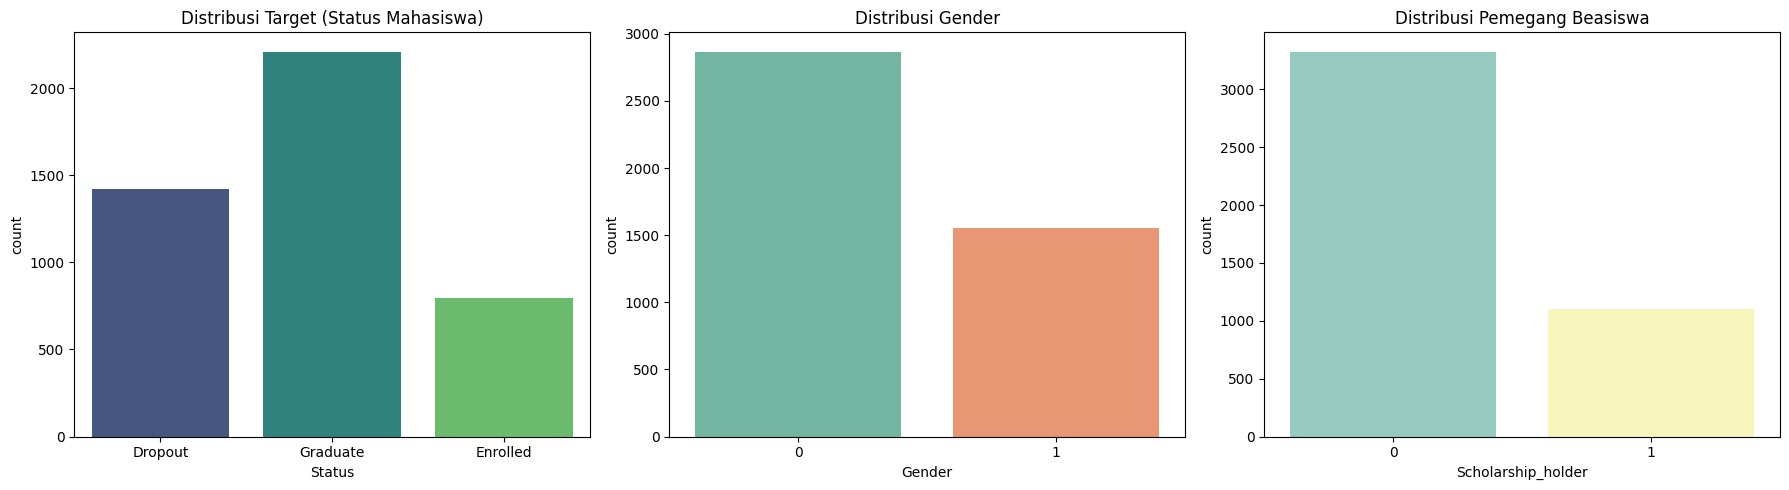

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Target (Status)
sns.countplot(data=df, x='Status', palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi Target (Status Mahasiswa)')

# Distribusi Gender (1=Male, 0=Female)
sns.countplot(data=df, x='Gender', palette='Set2', ax=axes[1])
axes[1].set_title('Distribusi Gender')

# Distribusi Pemegang Beasiswa (1=Yes, 0=No)
sns.countplot(data=df, x='Scholarship_holder', palette='Set3', ax=axes[2])
axes[2].set_title('Distribusi Pemegang Beasiswa')

plt.tight_layout()
plt.show()

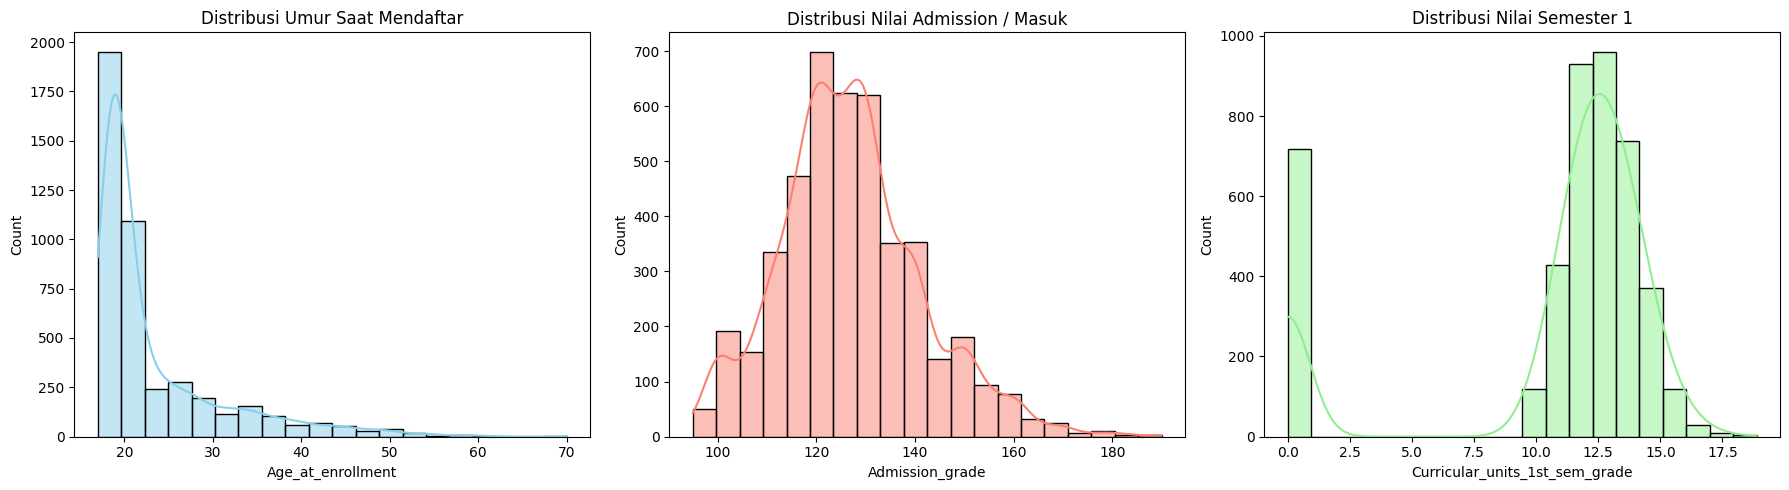

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Umur saat mendaftar
sns.histplot(df['Age_at_enrollment'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Umur Saat Mendaftar')

# Distribusi Nilai Masuk
sns.histplot(df['Admission_grade'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribusi Nilai Admission / Masuk')

# Distribusi Rata-rata Nilai Semester 1
sns.histplot(df['Curricular_units_1st_sem_grade'], bins=20, kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Distribusi Nilai Semester 1')

plt.tight_layout()
plt.show()

### EDA Multivariate

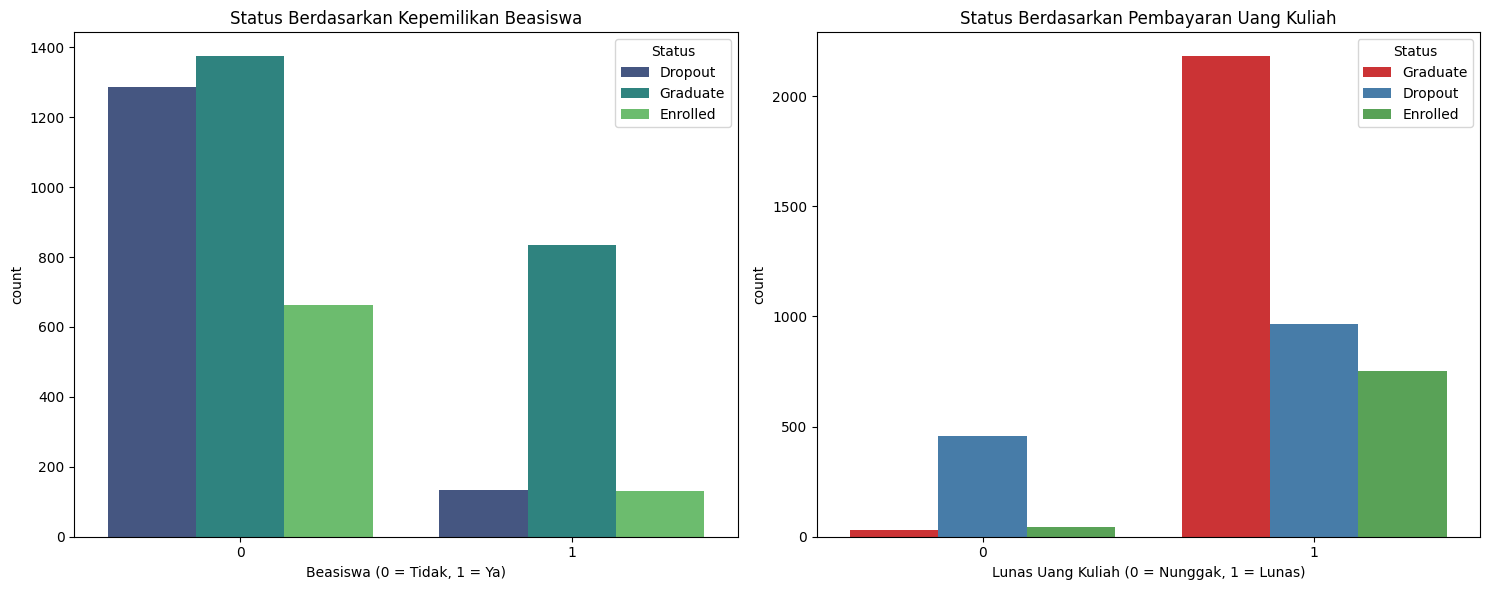

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Beasiswa vs Status
sns.countplot(data=df, x='Scholarship_holder', hue='Status', palette='viridis', ax=axes[0])
axes[0].set_title('Status Berdasarkan Kepemilikan Beasiswa')
axes[0].set_xlabel('Beasiswa (0 = Tidak, 1 = Ya)')

# Tunggakan Uang Kuliah vs Status
sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', palette='Set1', ax=axes[1])
axes[1].set_title('Status Berdasarkan Pembayaran Uang Kuliah')
axes[1].set_xlabel('Lunas Uang Kuliah (0 = Nunggak, 1 = Lunas)')

plt.tight_layout()
plt.show()

/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_22896/1712705497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', palette='pastel', ax=axes[0])
/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_22896/1712705497.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', palette='Set3', ax=axes[1])


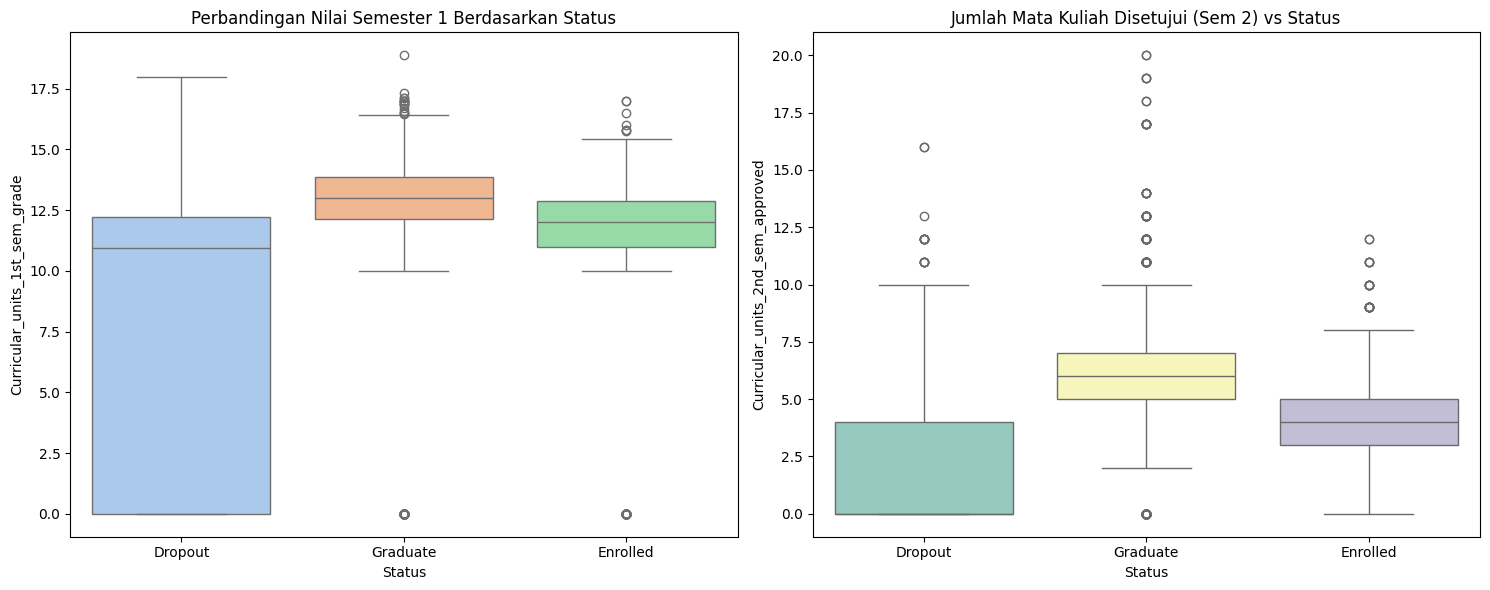

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Nilai Semester 1 vs Status
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', palette='pastel', ax=axes[0])
axes[0].set_title('Perbandingan Nilai Semester 1 Berdasarkan Status')

# Jumlah SKS yang di-approve di Semester 2 vs Status
sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', palette='Set3', ax=axes[1])
axes[1].set_title('Jumlah Mata Kuliah Disetujui (Sem 2) vs Status')

plt.tight_layout()
plt.show()

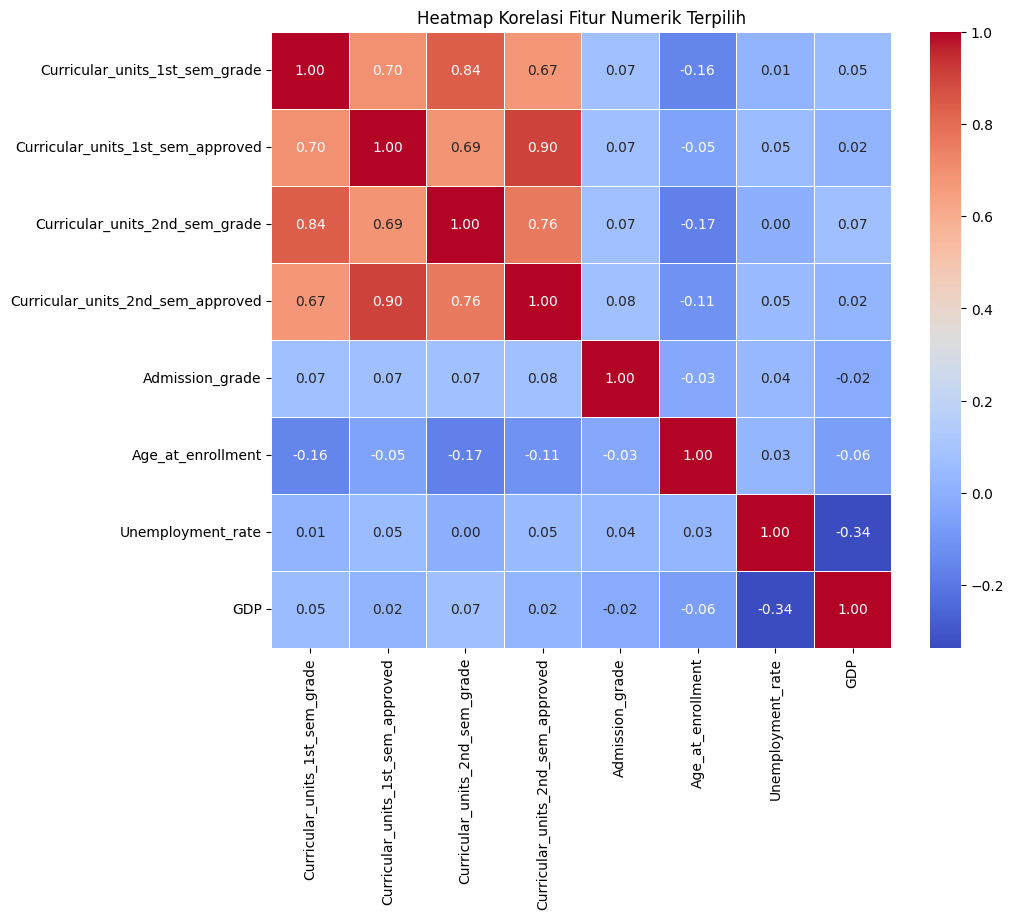

In [66]:
# Memilih beberapa fitur akademik dan makro ekonomi utama
cols_to_corr = ['Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_approved', 
                'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_approved',
                'Admission_grade', 'Age_at_enrollment', 'Unemployment_rate', 'GDP']

plt.figure(figsize=(10, 8))
correlation_matrix = df[cols_to_corr].corr()

# Membuat Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik Terpilih')
plt.show()

## Data Preparation / Preprocessing

In [67]:
# Inisialisasi LabelEncoder
le = LabelEncoder()

# Melakukan encoding pada kolom Status
df['Status_encoded'] = le.fit_transform(df['Status'])

# Melihat hasil mapping class-nya
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping Label Status:", class_mapping)

# Drop kolom Status yang lama (teks) dan gunakan yang baru untuk X dan y
X = df.drop(columns=['Status', 'Status_encoded'])
y = df['Status_encoded']

Mapping Label Status: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [68]:
# Membagi data dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah baris data latih (X_train): {X_train.shape[0]}")
print(f"Jumlah baris data uji (X_test): {X_test.shape[0]}")

Jumlah baris data latih (X_train): 3539
Jumlah baris data uji (X_test): 885


In [69]:
# Inisialisasi scaler
scaler = StandardScaler()

# Fit dan transform hanya pada X_train untuk mencegah Data Leakage, lalu transform pada X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ubah kembali ke format DataFrame agar mudah dilihat
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Cek hasil standarisasi
X_train_scaled.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
0,-0.29202,1.392028,-0.556229,0.185979,0.347852,3.286048,-0.960935,-0.122435,-1.121950,-1.389609,...,-0.210957,2.836043,1.700121,1.250659,1.838465,0.304781,-0.195530,0.872138,-1.103473,0.339595
1,-0.29202,1.163255,-0.556229,0.134079,0.347852,-0.355393,0.031460,-0.122435,-1.186204,-1.389609,...,1.297276,-0.283546,-0.552829,-0.765664,-1.464407,-1.949336,6.822546,0.421006,1.795972,-0.756629
2,-0.29202,1.449221,-0.556229,0.073050,0.347852,3.286048,0.554172,-0.122435,-1.186204,1.025249,...,-0.210957,-0.283546,-0.102239,1.754739,-0.143258,0.056446,-0.195530,1.473648,1.143597,-1.795621
3,-0.29202,-0.152186,-0.556229,0.105246,0.347852,-0.355393,-0.582158,-0.122435,-1.186204,-1.389609,...,-0.210957,-0.283546,-0.102239,-0.513624,0.517316,0.502175,-0.195530,0.308223,-0.523584,0.779846
4,-0.29202,-0.094993,-0.556229,0.311882,0.347852,-0.355393,0.705683,-0.122435,1.126943,0.959983,...,-0.210957,-0.283546,0.798941,-0.009543,0.847603,0.864762,-0.195530,-0.293287,0.128791,0.757833


## Modeling

In [70]:
rf_model = RandomForestClassifier(n_estimators=100, 
                                  random_state=42,
                                  class_weight='balanced')

rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluation

Akurasi Random Forest: 0.7774

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       284
    Enrolled       0.59      0.37      0.46       159
    Graduate       0.79      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.78      0.76       885



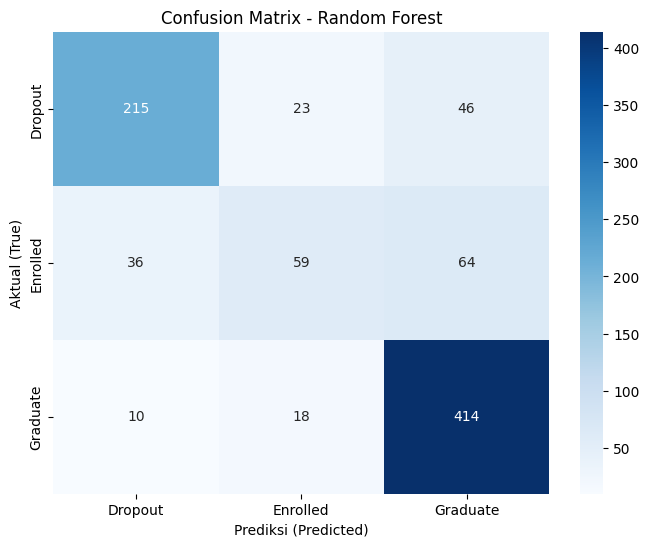

In [71]:
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Akurasi Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}\n")

print("=== CLASSIFICATION REPORT ===")
target_names = le.classes_ # Mengambil nama kelas asli: Dropout, Enrolled, Graduate
print(classification_report(y_test, y_pred_rf, target_names=target_names))

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi (Predicted)')
plt.ylabel('Aktual (True)')
plt.show()

/var/folders/mw/0ktg0s2n021d3v7pjlsk81sc0000gp/T/ipykernel_22896/3791854013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp, y=feature_imp.index, palette='magma')


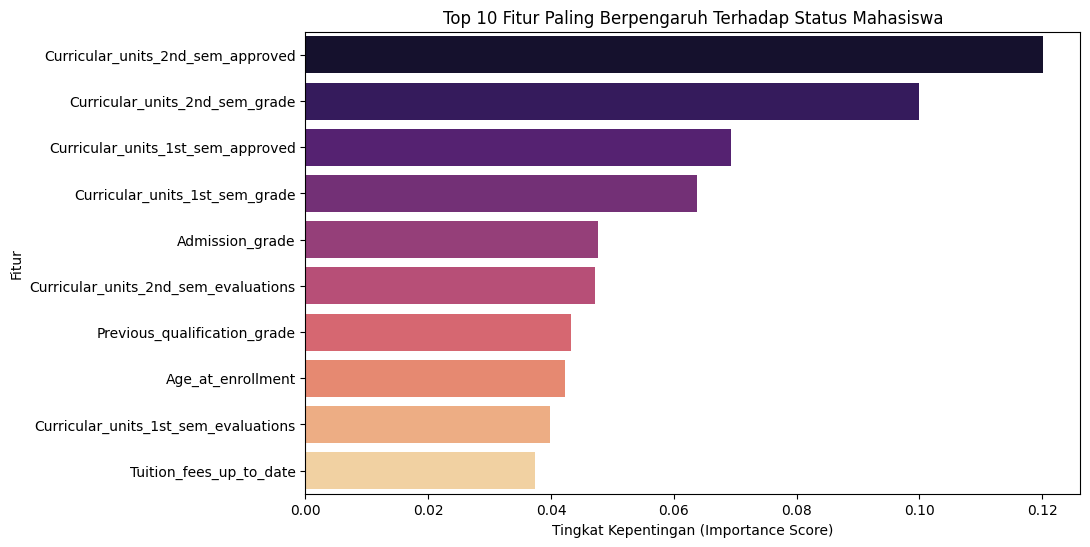

In [72]:
# 4. Memvisualisasikan Feature Importance
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp, y=feature_imp.index, palette='magma')
plt.title('Top 10 Fitur Paling Berpengaruh Terhadap Status Mahasiswa')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur')
plt.show()

In [73]:
# Simpan model RF, Scaler, dan Label Encoder ke format .joblib

joblib.dump(rf_model, 'model/random_forest_model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(le, 'model/label_encoder.joblib')

print("\nModel, Scaler, dan Label Encoder berhasil disimpan")


Model, Scaler, dan Label Encoder berhasil disimpan


In [83]:
new_df = df.copy()
new_df.drop(columns=['Status', 'Status_encoded'], inplace=True)
new_df.to_csv('dataset/data_for_inference.csv', sep = ';', index=False)

In [82]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
